# Actividad 2: M2003B
Author: A. Ramirez-Morales (andres.ramirez@tec.mx)

## Instrucciones:
- Active el kernel proveniente de `Anaconda`
- Complete las funciones donde vea líneas de código inconclusas
- Use comentarios para documentar de manera integral sus funciones
- Pruebe sus funciones con distintos parámetros
- Aumente las explicaciones en el Markdown y en el código
- Procure NO usar chatGPT ú otra tecnología similar, usted tiene la capacidad intelectual suficiente para resolverlo por usted mismo
- Use la documentación oficial de las librerías que se utilizan
- Se entrega un archivo PDF CANVAS como lo indique el profesor


In [2]:
# cargar librerías básicas
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, shapiro

##
## 1. Regresión lineal - decenso del gradiente

### 1.1 Cargar y visualizar los datos
Buscamos los archivos:
- `.../data/tutorial_1_data/linear_training.npy`
- `.../data/tutorial_1_data/linear_testing.npy`.

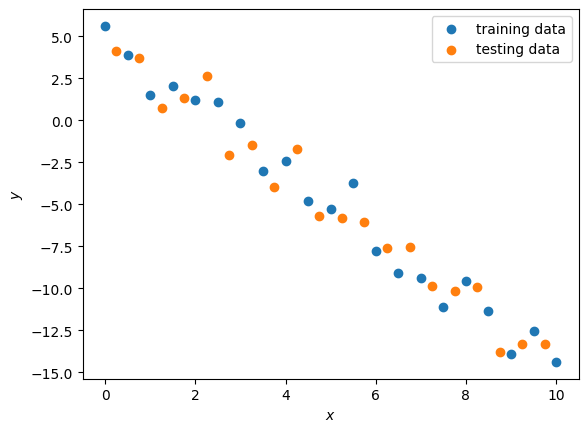

In [3]:
xy_training = np.load('../Data/linear_training.npy')
xy_testing = np.load('../Data/linear_testing.npy')
x = xy_training[:, 0]
y = xy_training[:, 1]
x_test = xy_testing[:, 0]
y_test = xy_testing[:, 1]

# graficamos
plt.scatter(x, y, label='training data')
plt.scatter(x_test, y_test, label='testing data')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show()

Esta son los datos a los cuales intentaremos ajustar una recta. Queremos ver qué tan cerca podemos llegar de los valores verdaderos de la pendiente y la intersección con el eje $y$ que introdujimos manualmente.

### 1.2  Definir la función de pérdida

Para lograr un buen ajuste, primero debemos definir qué significa un buen ajuste. En una situación donde estamos tratando de predecir un número, es común usar el **error cuadrático medio** (*Mean Squared Error*, MSE). Este se define como:

$$
L^{\rm{MSE}} = \frac{1}{N}\sum_i^N \big(y_i - f(x_i) \big)^2
$$

donde $y_i$ es el valor *verdadero* en los datos y $f(x_i)$ es el valor predicho.

*Ejercicio:*

Complete la siguiente función:


In [4]:
def MSE(y_true, y_pred):
    '''
    Esta función calcula el error cuadrático medio de valores predecidos contra valores reales, sus inputs son los siguientes

    inputs:
    y_true: (np.array(float64)) valor real de y
    y_pred: (np.array(float64)) valor predecido de y
    
    output:
    mse: (flloat(64))
    '''
    N = y_true.shape[0]
    
    # calcular la MSE
    # no use una loop
    ### empiece su codigo aqui ### (alrededor de 1 linea de code)
    mse = np.square(y_true-y_pred).mean()
    ### aqui acaba el codigo ###
    
    return mse

In [5]:
# pruebe su función
y_true = np.array([1, 2, 3])
y_pred = np.array([1.1, 1.9, 3])
print('MSE = ' + str(MSE(y_true, y_pred)))

MSE = 0.006666666666666678


**Salida esperada**: 

<table>
  <tr>
    <td>MSE</td>
    <td> 0.006666666666666678</td> 
  </tr>
</table>

### 1.3 Encontrar el gradiente

Para encontrar el mínimo de la función de pérdida (minimizar el error), necesitamos calcular el gradiente de la pérdida con respecto a los parámetros del modelo. Como nuestros datos parecen lineales, usemos una forma simple de:

$$
f(x_i) = m x_i + b
$$

Escribimos esto aplicando la regla de la cadena, como preparación para el caso de redes neuronales profundas.

#### Derivada parcial con respecto a $m$

$$
\frac{\partial}{\partial m} L^{\rm{MSE}} = \frac{1}{N} \sum_{i=1}^N -2\left(y_i - f(x_i)\right) \cdot \frac{\partial f(x_i)}{\partial m}
$$

Como $ \frac{\partial f(x_i)}{\partial m} = x_i $, esto se convierte en:

$$
\frac{\partial}{\partial m} L^{\rm{MSE}} = \frac{1}{N} \sum_{i=1}^N -2\left(y_i - f(x_i)\right) \cdot x_i
$$

#### Derivada parcial con respecto a $b$

$$
\frac{\partial}{\partial b} L^{\rm{MSE}} = \frac{1}{N} \sum_{i=1}^N -2\left(y_i - f(x_i)\right) \cdot \frac{\partial f(x_i)}{\partial b}
$$

Como $\frac{\partial f(x_i)}{\partial b} = 1 $, esto se convierte en:

$$
\frac{\partial}{\partial b} L^{\rm{MSE}} = \frac{1}{N} \sum_{i=1}^N -2\left(y_i - f(x_i)\right)
$$


### 1.4 Calcular la pérdida y el gradiente juntos

*Ejercicio*
Este parte del ejercicio será llamado **"propagación hacia adelante"** (*forward propagation*) cuando lleguemos a las redes neuronales. Queremos una función que reciba:

- los parámetros del modelo $ m $ y $b$,
- los datos de entrada,
- los valores verdaderos de $y$ ,

y que calcule y devuelva la **pérdida** y el **gradiente** (tanto para $m$ como para $b$.

Complete la siguiente función de propagación hacia adelante:

In [6]:
def propagate(m, b, X, Y):
    '''
    Implementa la función de pérdida y su gradiente

    Argumentos:
    m -- escalar, pendiente de la recta
    b -- escalar, sesgo (intersección)
    X -- np.array, datos de entrada
    Y -- valores verdaderos

    Regresa:
    loss -- Error cuadrático medio
    dm -- gradiente de la pérdida con respecto a m
    db -- gradiente de la pérdida con respecto a b
    '''
    ### Implemente su code aqui ###
    y_pred = m*X + b
    loss = MSE(Y,y_pred)
    ## fin de code ###
    
    ### encontrar gradiente
    ### Implemente su code aqui ###
    dm =  -2*((Y-y_pred)*X).mean() 
    db =  -2*((Y-y_pred)).mean()
    ## fin code ###
    
    # chequeos de sanidad
    assert(dm.dtype == float)
    assert(db.dtype == float)
    
    # este nos crea una tabla "look-up", facilita 
    grads = {'dm': dm,
             'db': db
            }
    
    return grads, loss

*Ejercicio:*

Implemente su función

In [7]:
m, b, X, Y = 1.0, 2.5, np.array([1, 2, 3, 4]), np.array([1.2, -2.3, 3.0, 4.5])
grads, loss = propagate(m, b, X, Y)
print('dm = ' + str(grads['dm']))
print('db = ' + str(grads['db']))
print('MSE = ' + str(loss))

dm = 15.7
db = 6.8
MSE = 15.444999999999999


**Salida esperada**: 

<table>
  <tr>
    <td>dm</td>
    <td>15.7</td> 
  </tr>
  <tr>
    <td>db</td>
    <td>6.8</td> 
  </tr>
  <tr>
    <td>MSE</td>
    <td>15.444999999999999</td> 
  </tr>
</table>


### 1.5 Realizar la optimización

**Ejercicio:** Escriba la función de optimización. El objetivo es aprender los valores de $m$ y $b$ minimizando la función de pérdida.  

Para un parámetro $\theta$, la regla de actualización es:

$$
\theta = \theta - \alpha \cdot d\theta
$$

 donde $\alpha$ es la **tasa de aprendizaje** (*learning rate*) y $d\theta$ es la derivada de la pérdida con respecto a $theta$.


In [8]:
def optimize(m, b, X, Y, num_iterations, learning_rate, print_loss=False):
    '''
    La función encuentra los valores óptimos de m y b ejecutando un algoritmo de descenso por gradiente

    Argumentos:
    m -- escalar, pendiente de la recta
    b -- escalar, sesgo (intersección)
    X -- np.array, datos de entrada
    Y -- valores verdaderos
    num_iterations -- número de iteraciones del ciclo de optimización
    learning_rate -- tasa de aprendizaje de la regla de actualización del descenso por gradiente
    print_loss -- True para imprimir la pérdida cada 100 pasos

    Regresa:
    params -- diccionario que contiene la pendiente m y el sesgo b
    grads -- diccionario que contiene los gradientes de la pendiente y el sesgo con respecto a la función de pérdida
    losss -- lista de todas las pérdidas calculadas durante la optimización, se usará para graficar la curva de aprendizaje
    '''
    
    losss = []
    slopes = []
    biases = []
    
    for i in range(num_iterations):
        slopes.append(m)
        biases.append(b)
        
        # loss and caculate gradient
        ### empiece code aqui ### (cerca 1 lineas de code)
        grads, loss = propagate(m,b,X,Y)
        ### termine codigo aqui ###
        
        # obtenga las derivadas
        ### empiece code aqui ### (cerca 2 lineas de code)
        dm = grads['dm']
        db = grads['db']
        ### termine ###
        
        # update rule
        ### empezar code aqui ### (cerca 2 lineasa de code)
        m = m - learning_rate*dm
        b = b - learning_rate*db
        ### terminar codigo aqui ###
        
        # guardar la loss
        losss.append(loss)
        
        # imprimir loss cada 100 training iterations
        if print_loss and i % 100 == 0:
            print('loss after iteration %i: %f' %(i, loss))
            
    params = {'m': m,
              'b': b
             }
    grads = {'dm': dm,
             'db': db
            }
    
    return params, grads, losss, slopes, biases

**Ejercicio:** Ahora usa la función `optimize` para encontrar la mejor recta que se ajuste a los datos, usando como suposición inicial $m = 0$ y $b = 0$.  Por ahora, utilize una **tasa de aprendizaje** de $0.01$ y realiza al menos **1000 iteraciones** de entrenamiento.


In [9]:
# complete codigo
params, grads, losss, slopes, biases = optimize(0, 0, x, y, 1000, 0.01)

Vamos a graficar los resultados para ver si el entrenamiento funcionó.  

- El panel izquierdo debe mostrar la pérdida MSE, la cual debería disminuir en cada paso de entrenamiento.  
- Los siguientes dos paneles muestran el valor de la pendiente y la intersección con el eje $y$ en cada paso de entrenamiento.  

Estos valores deberían acercarse asintóticamente a aproximadamente -2 y 5, respectivamente.  

Si  esto no ocurre, debe depurar el código de `optimize` anterior.


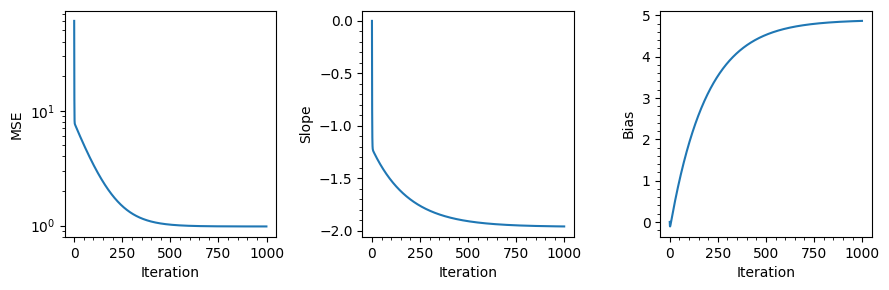

In [10]:
plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.plot(losss)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.yscale('log')
plt.minorticks_on()

plt.subplot(1, 3, 2)
plt.plot(slopes)
plt.xlabel('Iteration')
plt.ylabel('Slope')
plt.minorticks_on()

plt.subplot(1, 3, 3)
plt.plot(biases)
plt.xlabel('Iteration')
plt.ylabel('Bias')
plt.minorticks_on()

plt.tight_layout()

### 1.6 Resultados
Ahora grafique los resultados de las predicciones comparados con los valores de prueba (test)

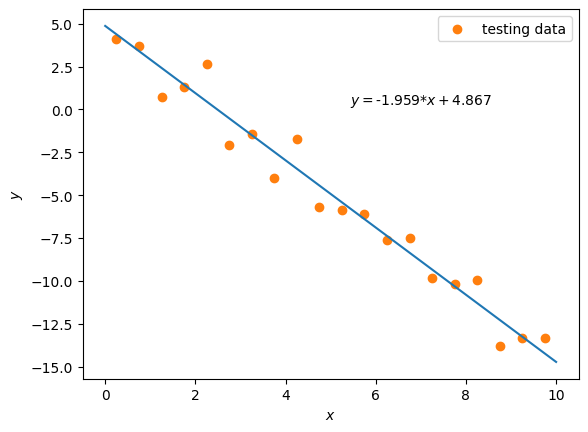

In [11]:
xrange = np.linspace(0, 10)
y_pred = xrange * params['m'] + params['b']
plt.plot(xrange, y_pred)
plt.scatter(x_test, y_test, color='C1', label='testing data')
plt.text(7., 1, r'$y=$' + '{0:.3f}'.format(params['m']) + r'$*x + $' + '{0:.3f}'.format(params['b']),
         ha='center', va='top')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show()

Observa que la pérdida es menor para el conjunto de entrenamiento. Esto se debe a que nuestro modelo se entrena para minimizar la pérdida en esos datos. Sin embargo, las pérdidas siguen siendo similares, por lo que no parece que hayamos sobreajustado los datos.

### 1.6 Ejercicios de Tarea
1. ¿Cuál es el efecto de la tasa de aprendizaje? Intenta variar la tasa de aprendizaje entre $10^{-3}$ y $1$. ¿Qué sucede cuando la tasa de aprendizaje es grande? ¿Por qué?

Con tasas muy ggrandes oscila, con tazas muy chicas vanza muy lento. Esto es el caso debido a que la tasa de aprendizaje controla que tan rápido avanzamos por el gradiente, en el caso de uno muy grande a veces nos pasarémoos del máximo, y lueggo regrsaremos a valores previos, en casos muy pequeños avanzamos muy poco a lo largo del gradiente

2. ¿Cómo cambiaría el procedimiento si los datos tuvieran forma curva? Carga los archivos `../data/tutorial_1_data/linear_regression_curved_training.npy` y `../data/tutorial_1_data/linear_regression_curved_test.npy` y encuentra una función que ajuste la curva.

Como experimento mental adicional, este ejemplo y el ejemplo curvo solo tienen una pieza de información de entrada (es decir, $x$). ¿Cómo generalizaríamos el esquema a más de 1 variable de entrada? Ahora, cada 'evento' $x_i$ es en realidad un vector con $j$ dimensiones. Cambiaré la notación y escribiré todo el conjunto de datos como $X^i_j$, donde los componentes inferiores representan el vector de información, y el componente superior representa los diferentes 'eventos' o puntos de datos. Desarrollaremos esto más en la siguiente sección, cuando exploremos la regresión logística.


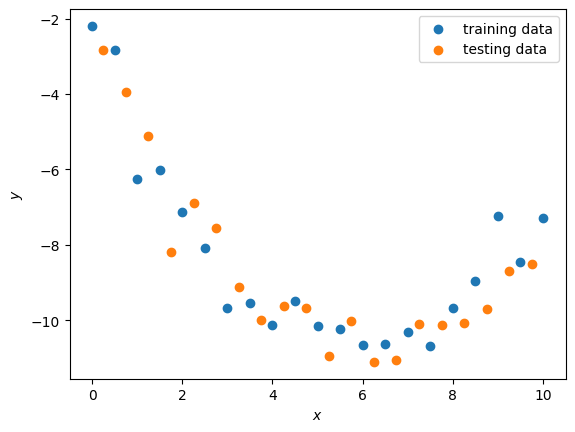

In [12]:
xy1_training = np.load('../Data/linear_regression_curved_training.npy')
xy1_testing = np.load('../Data/linear_regression_curved_test.npy')
x1 = xy1_training[:, 0]
y1 = xy1_training[:, 1]
x_test1 = xy1_testing[:, 0]
y_test1 = xy1_testing[:, 1]
# graficamos
plt.scatter(x1, y1, label='training data')
plt.scatter(x_test1, y_test1, label='testing data')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show()

In [15]:
def propagate_curve(a, b, c, X, Y):
    '''
    Implementa la función de pérdida y su gradiente

    Argumentos:
    m -- escalar, pendiente de la recta
    b -- escalar, sesgo (intersección)
    X -- np.array, datos de entrada
    Y -- valores verdaderos

    Regresa:
    loss -- Error cuadrático medio
    dm -- gradiente de la pérdida con respecto a m
    db -- gradiente de la pérdida con respecto a b

    
    Entrena en log-espacio: ln(y) = m*X + b
    
    '''
    y_hat = a*(X**2) + b*X + c
    loss = MSE(Y, y_hat)

    n = len(X)
    da = (2/n) * np.sum((y_hat - Y) * (X**2))
    db = (2/n) * np.sum((y_hat - Y) * X)
    dc = (2/n) * np.sum(y_hat - Y)

    grads = {"da": da, "db": db, "dc": dc}
    return loss, grads

In [25]:
def optimize_curve(a, b, c, X, Y, num_iterations=6000, learning_rate=0.0001, print_loss=False):
    '''
    La función encuentra los valores óptimos de a, b y c ejecutando un algoritmo de descenso por gradiente

    Argumentos:
    a -- escalar, coeficiente cuadrático
    b -- escalar, coeficiente lineal
    c -- escalar, término independiente
    X -- np.array, datos de entrada
    Y -- valores verdaderos
    num_iterations -- número de iteraciones del ciclo de optimización
    learning_rate -- tasa de aprendizaje de la regla de actualización del descenso por gradiente
    print_loss -- True para imprimir la pérdida cada 100 pasos

    Regresa:
    params -- diccionario que contiene la pendiente m y el sesgo b
    grads -- diccionario que contiene los gradientes de la pendiente y el sesgo con respecto a la función de pérdida
    losss -- lista de todas las pérdidas calculadas durante la optimización, se usará para graficar la curva de aprendizaje
    '''
    
    a_hist, b_hist, c_hist, loss_hist = [], [], [], []
    grads = {"da": 0.0, "db": 0.0, "dc": 0.0}

    for i in range(num_iterations):
        loss, grads = propagate_curve(a, b, c, X, Y)
        a -= learning_rate * grads["da"]
        b -= learning_rate * grads["db"]
        c -= learning_rate * grads["dc"]

        a_hist.append(a); b_hist.append(b); c_hist.append(c); loss_hist.append(loss)
        if print_loss and (i % max(1, num_iterations//10) == 0):
            print(f"Iter {i}: loss={loss:.6f} | a={a:.4f}, b={b:.4f}, c={c:.4f}")

    return a, b, c, grads, loss, a_hist, b_hist, c_hist, loss_hist

In [26]:
a0, b0, c0 = 0.0, 0.0, 0.0
a, b, c, grads, loss, a_hist, b_hist, c_hist, loss_hist = optimize_curve(a=a0, b=b0, c=c0, X=x1, Y=y1, num_iterations=10000, learning_rate=1e-5)

print(f'y ≈ {a:.4f}*x^2 + {b:.4f}*x + {c:.4f}')

y ≈ 0.0171*x^2 + -1.2504*x + -0.5479


In [27]:
# Predicciones

y_pred  = a*(x_test1**2) + b*x_test1 + c

# Errores
print(f'MSE: {MSE(y_test1, y_pred):.6f}')

MSE: 10.615059


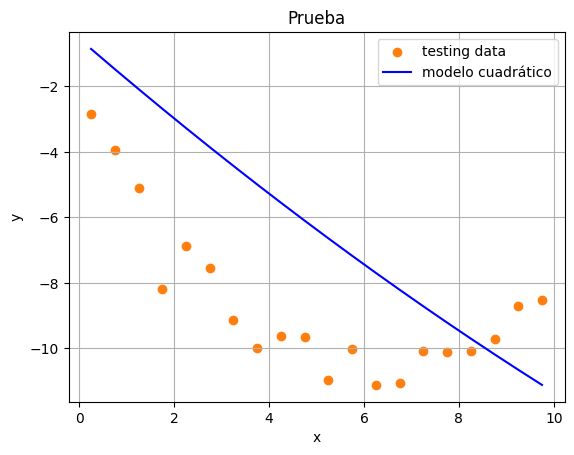

In [24]:
plt.scatter(x_test1, y_test1, color='C1', label="testing data")
plt.plot(x_test, y_pred, color="blue", label="modelo cuadrático")
plt.title("Prueba"); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.grid(True)

plt.show()

##
## 2. Regresión lineal - método analítico

### 2.1 Cargar y visualizar los datos

In [13]:
import pandas as pd
data = pd.read_csv('../Data/linear_data.csv')
X = data['X']
Y = data['Y']

### 2.2 Modelo lineal:
$$y_i = \beta_0 + \beta_1x_i + \epsilon_i$$

**Ejercicio:** Demuestre que:

$$
\hat{\beta_1} = \frac{\sum_{i=1}^n x_i y_i - n \overline{x} \overline{y}}{\sum_{i=1}^n x_i^2 - n \overline{x}^2}
$$



**Ejercicio:** Complete la siguiente función para obtener los estimadores de $\beta_0,\: \sigma$ y $\beta_1$.

In [14]:
def simple_linear_regression(x, y):
    """
    Esta función hace una regresión lineal
    Inputs:
        x: np.array(float64) es la variable independiente de nuestros datos

        y: np.array(float64) es la variable dependiente de nuestros datos
    
    Outputs:
        beta_0_estimador: float64 es el intercepto con el eje y
        beta_1_estimador: float64 es el coeficiente de x
        sigma_estimator: 
    """
    # convertir listas de entrada a arrays de numpy
    x = np.array(x)
    y = np.array(y)
    
    # calcular promedios de x, y
    x_mean = 
    y_mean = 
    
    # calcular numerador y denominador para beta_1
    numerator = 
    denominator = 
    
    # Calcular beta_1 (pendiente)
    beta_1_estimador = 
    
    # Calcular beta_0 (intersección)
    beta_0_estimador =

    # Calcular valores predichos
    y_hat = 
    
    # Calcular residuos
    residuals = 
    
    # Estimar sigma (desviación estándar de los errores)
    n = 
    sigma_estimador = 
    
    return beta_0_estimador, beta_1_estimador, sigma_estimador

SyntaxError: invalid syntax (2631728198.py, line 19)

Pruebe su función

In [ ]:
beta_0_estimador, beta_1_estimador, sigma_estimador = simple_linear_regression(X, Y)
print(f"Estimated beta_0 (intercept): {beta_0_estimador}")
print(f"Estimated beta_1 (slope): {beta_1_estimador}")
print(f"Estimated sigma (error): {sigma_estimador}")